In [1]:
import pandas as pd
import seaborn as sns

# CNN-1D -> GCN Model

### Hidden size, learning rate, weight decay

Tested over 3 seeds:

* Hidden size: 32, 64, 96, 128
* Learning rate: 0.0003, 0.0005, 0.001, 0.002
* Weight decay: 0, 1e-5, 1e-4, 1e-3, 5e-3

Fixed:

* Batch size: 32
* Dropout: 0.1
* Loss: Huber
* Epochs: 400
* Patience: 30

Total: 33 runs.

File: "results/hyperpar_tuning_CNN1D_GCN_round_1.csv"

Results: More hidden size really improved the model by a lot.

Second round:
* Hidden size: 128, 160, 192, 256
* Learning rate: 0.002
* Weight decay: 1e-3
* Seeds: 145, 654, 223, 523
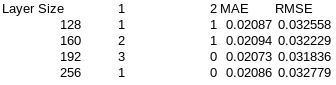

Optimum somewhere between 160 and 208, I'd assume. We do another sweep.

Round 3:

* Hidden size: 160, 176, 192, 208
* Learning rate: 0.002
* Weight decay: 1e-3
* Seeds: 317, 842, 191, 708

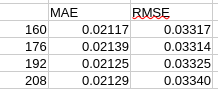

Sweet spot: 160 hidden size.

Round 4: Find best dropout

* Dropout: 0, 0.05, 0.1, 0.15, 0.2, 0.3
* Hidden size: 160
* Learning rate: 0.002
* Weight decay: 1e-3

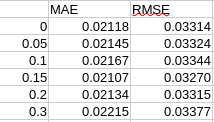

Sweet spot: 0.15 dropout.


### Taking overfitting into account. Redo hidden layer.

Round 1:
* Hidden size: 32, 64, 96, 128, 160
* Seeds: 145, 654, 223

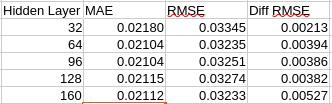

Decision: 64 is good moderate model, 160 is good but overfitting, 32 low chance of overfitting.
We take these three, then compare them on final test set.

## Pure MLP model
* Hidden size: 64 or 96
* Dropout: 0.2

### GCN-GRU model
* Hidden size 64, from 96 on hard overfit over 4 seeds.
* LR 0.0005
* Dropout 0.05

### GCN-MLP model

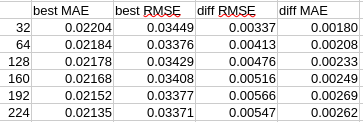
* Hidden size: 32 or 64
* Dropout: 0.3
* LR: 0.002 (even though 0.001 bit better, but this was due to one lucky run, 0.002 more consistent across seeds)

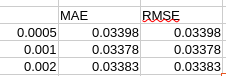

### GRU-GCN model

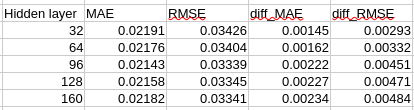

* Hidden size: 64 or 96 (96 might be overfitting already)
* Dropout: 0.2
* LR: 0.0008 (more stable over seeds)

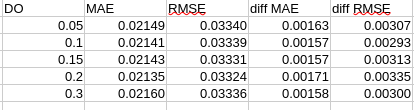

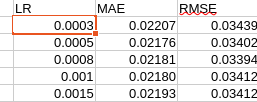

### Should we normalize the lane column?

Simple test on 532 seed with CNN1D GCN h32:

* With lane normalization
epoch 161 : train_loss=0.0197  val_loss=0.0133  train_rmse=0.0313  val_rmse=0.0329  val_mae=0.0211  best=0.0329

* Without lane normalization
epoch 107 : train_loss=0.0207  val_loss=0.0139  train_rmse=0.0327  val_rmse=0.0336  val_mae=0.0220  best=0.0336

We keep it for now


### Find best training epochs for each model

* 6 seeds, 11 models

In [3]:
df = pd.read_csv("results/best_epochs_final_train.csv")
summary = df.groupby("model_version")["best_epoch"].agg(["mean", "median", "std", "min", "max"])
summary["final_epoch"] = (summary["median"] + 0.5 * summary["std"]).round().astype(int)
print(summary)


                         mean  median        std  min  max  final_epoch
model_version                                                          
conv1d_gcn_attent  124.166667   132.0  29.982773   71  152          147
conv1d_gcn_hl160    93.333333    81.5  48.963932   58  190          106
conv1d_gcn_hl32     96.000000    96.5  38.584971   53  154          116
conv1d_gcn_hl64    108.000000   108.0  10.059821   96  120          113
gcn_gru            142.333333   149.5  19.866219  108  161          159
gcn_mlp_hl32        66.833333    66.0   9.196014   55   82           71
gcn_mlp_hl64        70.166667    66.5  26.194783   34  114           80
gru_gcn_hl64       146.666667   151.5  31.366649  110  179          167
gru_gcn_hl96       100.666667    97.0  28.890598   60  147          111
pure_mlp_hl64      121.000000   119.0  23.537205   95  159          131
pure_mlp_hl96      102.500000    95.0  29.337689   81  159          110


Exceptions where models have high variance with final epoch. Rather overtrain a bit than undertrain.